In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("AACHI Validation Started")

AACHI Validation Started


In [2]:
sensor = pd.read_csv("../dataset/final_irrigation_dataset.csv")

sensor.head()

,farm_id,region,crop,soil_moisture,soil_ph,temperature,rainfall,humidity,sunlight_hours,irrigation_type,...,ndvi,crop_disease_status,soil_fertility_score,weather_score,vegetation_score,moisture_stress_score,ai_crop_health_index,health_status,irrigation_recommendation,irrigation_level
0,FARM0001,North India,Wheat,0.740666,0.241206,0.140625,0.102295,0.739401,0.544240,Sprinkler,...,0.550000,Mild,0.490936,0.327440,0.550000,0.421481,0.450937,Moderate,No Irrigation Needed,Medium Irrigation
1,FARM0002,South USA,Soybean,0.275129,0.869347,0.765121,0.159733,0.419932,0.277129,Sprinkler,...,0.466667,Severe,0.572238,0.448262,0.466667,0.217431,0.443890,Moderate,High Irrigation,Medium Irrigation
2,FARM0003,South USA,Wheat,0.550258,0.829146,0.623488,0.865228,0.575447,0.704508,Drip,...,0.833333,Mild,0.689702,0.688054,0.833333,0.707743,0.728806,Good,Moderate Irrigation,Low Irrigation
3,FARM0004,Central USA,Maize,0.205916,0.261307,0.944052,0.650508,0.607394,0.170284,Sprinkler,...,0.233333,Severe,0.233611,0.733985,0.233333,0.428212,0.397555,Poor,High Irrigation,High Irrigation
4,FARM0005,Central USA,Cotton,0.264503,0.206030,0.950605,0.879939,0.311433,0.654424,Sprinkler,...,0.900000,Severe,0.235267,0.713992,0.900000,0.572221,0.588522,Moderate,High Irrigation,Medium Irrigation


In [3]:
print(sensor.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   farm_id                    500 non-null    str    
 1   region                     500 non-null    str    
 2   crop                       500 non-null    str    
 3   soil_moisture              500 non-null    float64
 4   soil_ph                    500 non-null    float64
 5   temperature                500 non-null    float64
 6   rainfall                   500 non-null    float64
 7   humidity                   500 non-null    float64
 8   sunlight_hours             500 non-null    float64
 9   irrigation_type            500 non-null    str    
 10  fertilizer_type            500 non-null    str    
 11  pesticide_usage_ml         500 non-null    float64
 12  sowing_date                500 non-null    str    
 13  harvest_date               500 non-null    str    
 14  total

In [4]:
print(sensor[[
    "soil_fertility_score",
    "weather_score",
    "vegetation_score",
    "moisture_stress_score",
    "ai_crop_health_index"
]].describe())

       soil_fertility_score  weather_score  vegetation_score  \
count            500.000000     500.000000        500.000000   
mean               0.492996       0.505969          0.503433   
std                0.207272       0.162996          0.292337   
min                0.031587       0.051148          0.000000   
25%                0.353281       0.384098          0.245833   
50%                0.500193       0.509673          0.516667   
75%                0.640938       0.618218          0.750000   
max                0.999282       0.932847          1.000000   

       moisture_stress_score  ai_crop_health_index  
count             500.000000            500.000000  
mean                0.502538              0.500757  
std                 0.210725              0.133201  
min                 0.034815              0.098098  
25%                 0.346589              0.416143  
50%                 0.497415              0.498373  
75%                 0.655779              0.592962  

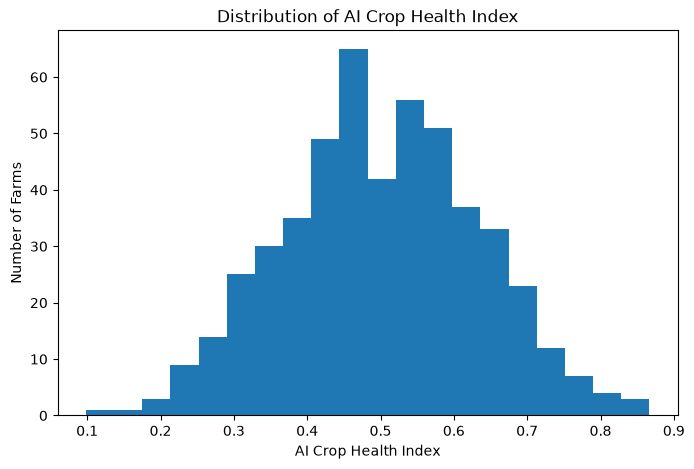

In [5]:
plt.figure(figsize=(8,5))

plt.hist(sensor["ai_crop_health_index"], bins=20)

plt.title("Distribution of AI Crop Health Index")
plt.xlabel("AI Crop Health Index")
plt.ylabel("Number of Farms")

plt.show()

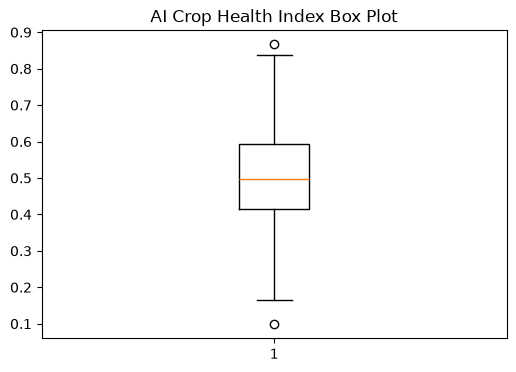

In [6]:
plt.figure(figsize=(6,4))

plt.boxplot(sensor["ai_crop_health_index"])

plt.title("AI Crop Health Index Box Plot")

plt.show()

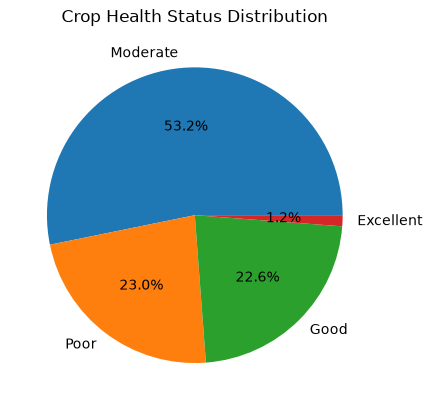

In [7]:
sensor["health_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Crop Health Status Distribution")

plt.ylabel("")

plt.show()

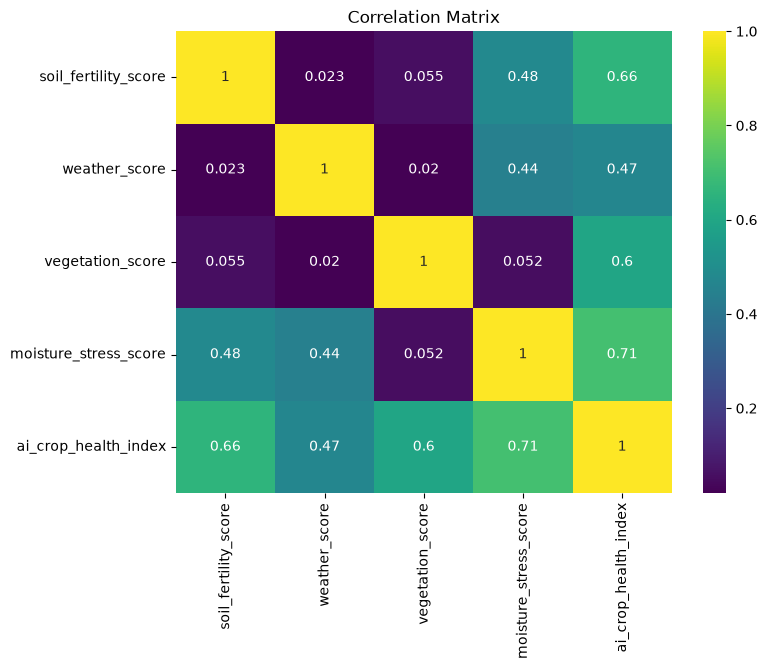

In [8]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    sensor[
        [
            "soil_fertility_score",
            "weather_score",
            "vegetation_score",
            "moisture_stress_score",
            "ai_crop_health_index"
        ]
    ].corr(),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
sensor.to_csv(
    "../dataset/final_validated_dataset.csv",
    index=False
)

print("Validated Dataset Saved Successfully!")

Validated Dataset Saved Successfully!


In [1]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Test probabilities
y_score = rf.predict_proba(X_test)

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=rf.classes_)

plt.figure(figsize=(10, 8))

for i in range(len(rf.classes_)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr,
        tpr,
        label=f"Class {rf.classes_[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Crop Recommendation")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

NameError: name 'rf' is not defined